Rozpoczynam zoptymalizowane przeszukiwanie siatki (Grid Search)...


/var/data/python/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.708204e+07, tolerance: 2.268e+04
  model = cd_fast.enet_coordinate_descent(
/var/data/python/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.343670e+07, tolerance: 2.317e+04
  model = cd_fast.enet_coordinate_descent(
/var/data/python/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.97


Najlepsze hiperparametry: {'preprocessor__num__polynomialfeatures__degree': 3, 'regressor__alpha': 0.1, 'regressor__l1_ratio': 0.9} 

=== PORÓWNANIE MODELU PIERWSZEGO Z KOŃCOWYM ===
                            Metryka Pierwszy Model (Tylko temp) Końcowy Model (Wszystkie cechy + ElasticNet)
        RMSE (im mniej, tym lepiej)                      630.13                                       443.46
         MAE (im mniej, tym lepiej)                      391.03                                       337.15
        MAPE (im mniej, tym lepiej)                      298.6%                                       221.4%
R^2 Train (im bliżej 1, tym lepiej)                       0.306                                        0.763


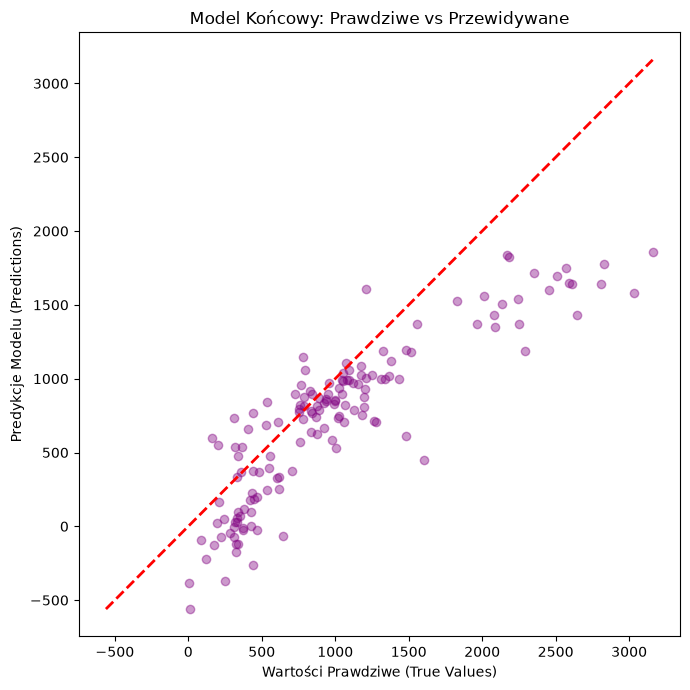

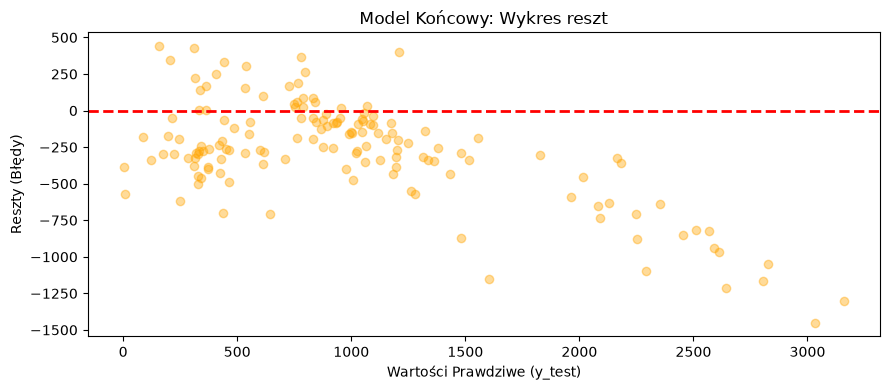

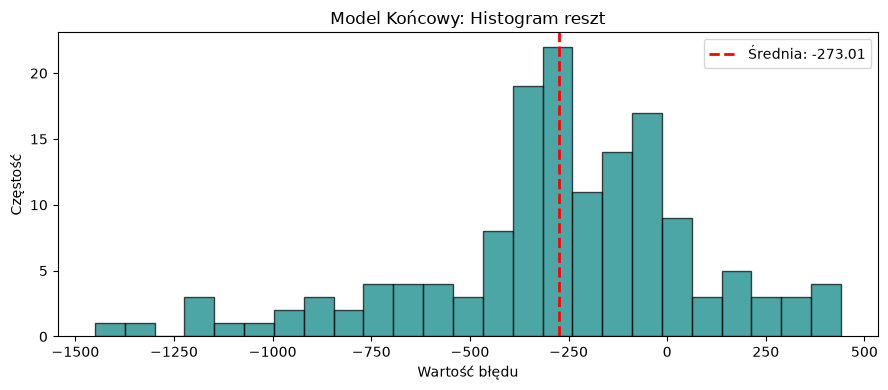


[SUKCES] Wykresy (final_true_vs_pred.png, final_residuals.png, final_residuals_hist.png) zostały pomyślnie zapisane!


In [10]:
# Import modułu do interakcji z systemem operacyjnym
import os
# Import funkcji do obliczania pierwiastka kwadratowego
from math import sqrt
# Import biblioteki do tworzenia wykresów i wizualizacji danych
import matplotlib.pyplot as plt
# Import klasy do automatycznego wymuszania całkowitych podziałów na osiach wykresu
from matplotlib.ticker import MaxNLocator
# Import biblioteki do zaawansowanych operacji wektorowych i macierzowych
import numpy as np
# Import biblioteki do manipulacji strukturami danych (DataFrame, Series)
import pandas as pd
# Import klasy umożliwiającej stosowanie transformacji do konkretnych podzbiorów kolumn
from sklearn.compose import ColumnTransformer
# Import estymatorów regresji liniowej: klasycznej oraz z regularyzacją L1+L2
from sklearn.linear_model import ElasticNet, LinearRegression
# Import funkcji do ewaluacji matematycznej modeli regresyjnych
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
# Import narzędzi do podziału danych oraz optymalizacji hiperparametrów
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
# Import klas do sekwencyjnego łączenia transformatorów i estymatorów w potok danych
from sklearn.pipeline import Pipeline, make_pipeline
# Import klas do inżynierii cech: kodowanie kategoryczne, normalizacja i skalowanie
from sklearn.preprocessing import (
    OneHotEncoder,
    PolynomialFeatures,
    PowerTransformer,
    StandardScaler,
)

# =====================================================================
# 1. WCZYTANIE I PRZYGOTOWANIE DANYCH
# =====================================================================

# Wczytanie surowego zbioru danych z pliku CSV do obiektu DataFrame
bike_data_raw = pd.read_csv("daily-bike-share.csv")
# Utworzenie głębokiej kopii struktury danych w celu uniknięcia modyfikacji pliku bazowego
bike_data = bike_data_raw.copy()

# Definicja nazwy zmiennej objaśnianej (celu predykcji)
target = "rentals"

# Deklaracja listy zmiennych o charakterze ciągłym (numerycznym)
numeric_features = ["temp", "atemp", "hum", "windspeed"]

# Deklaracja listy zmiennych dyskretnych/nominalnych (kategorycznych)
categorical_features = ["season", "mnth", "holiday", "weekday", "workingday", "weathersit"]

# =====================================================================
# KROK A: PIERWSZY MODEL (Regresja liniowa jednej zmiennej 'temp')
# =====================================================================

# Wydzielenie jednoelementowej macierzy cech wejściowych (zmienna 'temp') jako DataFrame
X_first = bike_data[["temp"]].copy()

# Wydzielenie wektora zmiennej objaśnianej (liczba rentals) jako Series
y_first = bike_data[target].copy()

# Podział danych na zbiór treningowy i testowy w proporcji 80:20 bez losowego mieszania chronologii
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_first, y_first, test_size=0.2, shuffle=False
)

# Inicjalizacja instancji klasycznego estymatora regresji liniowej
lr_model = LinearRegression()

# Estymacja współczynników strukturalnych modelu na danych treningowych
lr_model.fit(X_train_f, y_train_f)

# Generowanie predykcji dla zbioru treningowego w celu ewaluacji dopasowania modelu bazowego
y_predict_train_f = lr_model.predict(X_train_f)

# Generowanie predykcji dla zbioru testowego w celu weryfikacji zdolności generalizacyjnych modelu bazowego
y_predict_test_f = lr_model.predict(X_test_f)


# =====================================================================
# KROK B: ZAAWANSOWANY MODEL KOŃCOWY (Wszystkie cechy + Pipeline + ElasticNet)
# =====================================================================

# Konstrukcja wielowymiarowej macierzy cech z uwzględnieniem wszystkich zmiennych
X = bike_data[numeric_features + categorical_features].copy()

# Konstrukcja wektora zmiennej objaśnianej dla pełnego modelu
y = bike_data[target].copy()

# Wykonanie analogicznego podziału danych (80/20, chronologiczny) dla rozbudowanej przestrzeni cech
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
# Definicja strategii walidacji krzyżowej: 5-krotny podział blokowy bez mieszania chronologicznego
cv = KFold(n_splits=5, shuffle=False)

# Definicja sekwencyjnego potoku przetwarzania wstępnego dla podzbioru cech numerycznych
numeric_transformer = Pipeline(
    steps=[
        # Transformacja Yeo-Johnsona w celu stabilizacji wariancji i normalizacji rozkładów skośnych
        ("logtransformer", PowerTransformer()),
        # Standaryzacja cech (centrowanie do średniej=0, skalowanie do wariancji=1)
        ("standardscaler", StandardScaler()),
        # Generowanie interakcji nieliniowych oraz wyższych potęg cech bazowych
        ("polynomialfeatures", PolynomialFeatures()),
    ]
)

# Definicja potoku przetwarzania wstępnego dla podzbioru cech kategorycznych
categorical_transformer = Pipeline(
    steps=[
        # Kodowanie 1-z-N (One-Hot) z ignorowaniem nieznanych etykiet w zbiorze testowym
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Integracja podpotoków transformacji w jeden komponent przetwarzający kolumny na podstawie typu danych
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# Konstrukcja ostatecznego potoku danych łączącego preprocesor z estymatorem docelowym
final_pipeline = Pipeline(
    steps=[("preprocessor", preprocessor), ("regressor", ElasticNet())]
)

# Definicja dyskretnej przestrzeni hiperparametrów (siatki) podlegającej optymalizacji
params = {
    # Przestrzeń stopni transformacji wielomianowej
    "preprocessor__num__polynomialfeatures__degree":[1, 2, 3, 4, 5],
    # Przestrzeń siły kary regularyzacyjnej
    "regressor__alpha": [1e-3, 1e-2, 1e-1, 1.0],
    # Przestrzeń proporcji miksu kar L1 (Lasso) i L2 (Ridge)
    "regressor__l1_ratio": [0.1, 0.5, 0.9, 1.0],
}

# Inicjalizacja przeszukiwania siatki z walidacją krzyżową oraz współbieżnością procesową (wszystkie rdzenie CPU)
final_polynomial_regression_gridsearch = GridSearchCV(
    final_pipeline, params, scoring="neg_mean_squared_error", cv=cv, n_jobs=-1
)

print("Rozpoczynam zoptymalizowane przeszukiwanie siatki (Grid Search)...")
# Uruchomienie procesu optymalizacji parametrów modelu na pełnym zbiorze treningowym
final_polynomial_regression_gridsearch.fit(X_train, y_train)

# Ekstrakcja i wydruk zestawu hiperparametrów, który zminimalizował błąd średniokwadratowy
print(
    "\nNajlepsze hiperparametry:",
    final_polynomial_regression_gridsearch.best_params_,
    "\n",
)

# Pobranie w pełni zoptymalizowanego potoku danych z najlepszymi wagami
final_polynomial_regression_model = final_polynomial_regression_gridsearch.best_estimator_


# =====================================================================
# KROK C: ZADANIE DOMOWE - OBLICZANIE METRYK I PORÓWNANIE
# =====================================================================

# Generowanie predykcji ostatecznego modelu dla danych treningowych
y_pred_final_train = final_polynomial_regression_model.predict(X_train)

# Generowanie predykcji ostatecznego modelu dla danych testowych
y_pred_final_test = final_polynomial_regression_model.predict(X_test)

# Obliczenie pierwiastka błędu średniokwadratowego dla modelu końcowego na zbiorze testowym
final_rmse = sqrt(mean_squared_error(y_test, y_pred_final_test))

# Obliczenie średniego błędu absolutnego dla modelu końcowego na zbiorze testowym
final_mae = mean_absolute_error(y_test, y_pred_final_test)

# Obliczenie średniego błędu procentowego dla modelu końcowego na zbiorze testowym
final_mape = mean_absolute_percentage_error(y_test, y_pred_final_test)

# Obliczenie współczynnika determinacji R^2 na zbiorze treningowym dla modelu końcowego
final_r2_train = r2_score(y_train, y_pred_final_train)

# Obliczenie RMSE dla bazowego modelu na danych testowych
first_rmse = sqrt(mean_squared_error(y_test_f, y_predict_test_f))

# Obliczenie MAE dla bazowego modelu na danych testowych
first_mae = mean_absolute_error(y_test_f, y_predict_test_f)

# Obliczenie MAPE dla bazowego modelu na danych testowych
first_mape = mean_absolute_percentage_error(y_test_f, y_predict_test_f)

# Obliczenie R^2 dla bazowego modelu na danych treningowych
first_r2_train = r2_score(y_train_f, y_predict_train_f)

# Konstrukcja słownika strukturalnego agregującego wyliczone metryki
summary_data = {
    "Metryka": [
        "RMSE (im mniej, tym lepiej)",
        "MAE (im mniej, tym lepiej)",
        "MAPE (im mniej, tym lepiej)",
        "R^2 Train (im bliżej 1, tym lepiej)",
    ],
    "Pierwszy Model (Tylko temp)": [
        f"{first_rmse:.2f}",
        f"{first_mae:.2f}",
        f"{first_mape*100:.1f}%",
        f"{first_r2_train:.3f}",
    ],
    "Końcowy Model (Wszystkie cechy + ElasticNet)": [
        f"{final_rmse:.2f}",
        f"{final_mae:.2f}",
        f"{final_mape*100:.1f}%",
        f"{final_r2_train:.3f}",
    ],
}
# Konwersja słownika metryk do czytelnego formatu tabelarycznego DataFrame
comparison_df = pd.DataFrame(summary_data)
print("=== PORÓWNANIE MODELU PIERWSZEGO Z KOŃCOWYM ===")

# Wydruk tabeli metryk do konsoli z pominięciem domyślnego indeksu wierszy
print(comparison_df.to_string(index=False))


# =====================================================================
# KROK D: GENEROWANIE I ZAPISYWANIE WYKRESÓW DIAGNOSTYCZNYCH
# =====================================================================

# Inicjalizacja nowej figury wykresu o kwadratowych proporcjach (7x7 cali)
plt.figure(figsize=(7, 7))

# Wygenerowanie wykresu korelacji punktowej pomiędzy wartościami rzeczywistymi a predykcjami
plt.scatter(y_test, y_pred_final_test, alpha=0.4, color="purple")

# Wyznaczenie dziedziny wektora dla linii referencyjnej idealnego dopasowania (Y = X)
ideal_line = np.linspace(
    min(y_test.min(), y_pred_final_test.min()),
    max(y_test.max(), y_pred_final_test.max()),
    100,
)
# Nałożenie linii Y=X reprezentującej stuprocentową dokładność prognoz
plt.plot(ideal_line, ideal_line, color="red", linestyle="--", linewidth=2)

# Przypisanie etykiety osi odciętych
plt.xlabel("Wartości Prawdziwe (True Values)")

# Przypisanie etykiety osi rzędnych
plt.ylabel("Predykcje Modelu (Predictions)")

# Definicja nagłówka głównego wykresu korelacji
plt.title("Model Końcowy: Prawdziwe vs Przewidywane")

# Automatyczne dopasowanie marginesów figury w celu uniknięcia obcięcia opisów
plt.tight_layout()

# Serializacja i zapis wykresu korelacji do pliku graficznego PNG z rozdzielczością 120 DP
plt.savefig("final_true_vs_pred.png", dpi=120)

# Wyświetlenie histogramu w Jupyter Notebook
plt.show()

# Destrukcja obiektu figury w celu zwolnienia zasobów pamięci operacyjnej RA
plt.close()

# Obliczenie wektora reszt (błędów cząstkowych) dla zbioru testowego
final_errors = y_pred_final_test - y_test

# Inicjalizacja figury dla wykresu reszt w proporcjach panoramicznych
plt.figure(figsize=(9, 4))

# Konstrukcja wykresu rozrzutu reszt w funkcji wartości rzeczywistych
plt.scatter(y_test, final_errors, alpha=0.4, color="orange")

# Rysowanie linii referencyjnej błędu zerowego (Y=0)
plt.axhline(0, color="red", linestyle="--", linewidth=2)

# Przypisanie opisu osi 
plt.xlabel("Wartości Prawdziwe (y_test)")

# Przypisanie opisu osi 
plt.ylabel("Reszty (Błędy)")

# Definicja nagłówka głównego dla wykresu analizy reszt
plt.title("Model Końcowy: Wykres reszt")

# Optymalizacja marginesów geometrycznych wykresu
plt.tight_layout()

# Zapis graficzny rozkładu reszt do formatu PN
plt.savefig("final_residuals.png", dpi=120)

# Wyświetlenie wykresu w Jupyter Notebook
plt.show()

# Zwolnienie pamięci dedykowanej dla figury wykresu reszt
plt.close()

# Inicjalizacja figury dla analizy struktury rozkładu błędów (histogram)
plt.figure(figsize=(9, 4))

# Budowa histogramu częstości występowania poszczególnych wartości błędów (25 przedziałów)
plt.hist(final_errors, bins=25, color="teal", edgecolor="black", alpha=0.7)

# Nałożenie pionowej linii wskazującej matematyczną średnią arytmetyczną wszystkich błędów
plt.axvline(final_errors.mean(),color="red",linestyle="dashed",linewidth=2,label=f"Średnia: {final_errors.mean():.2f}",)

# Przypisanie nagłówka wykresu rozkładu częstości błędów
plt.title("Model Końcowy: Histogram reszt")

# Przypisanie opisu osi odciętych
plt.xlabel("Wartość błędu")

# Przypisanie opisu osi rzędnych
plt.ylabel("Częstość")

# Wyświetlenie legendy zawierającej etykietę linii średniej arytmetycznej błędów
plt.legend()

# Dopasowanie elementów kompozycji wykresu
plt.tight_layout()

# Zapis ostatecznego histogramu do pliku PN
plt.savefig("final_residuals_hist.png", dpi=120)

# Wyświetlenie histogramu w Jupyter Notebook
plt.show()

# Zamknięcie figury i finalne wyczyszczenie pamięci podręcznej modułu graficznego
plt.close()

# Komunikat końcowy informujący użytkownika o poprawnym zakończeniu procedury
print("\n[SUKCES] Wykresy (final_true_vs_pred.png, final_residuals.png, final_residuals_hist.png) zostały pomyślnie zapisane!")


# 🚴 Projekt Predykcji Wypożyczeń Rowerów – Porównanie Modelów

Projekt pokazuje ewolucję modelu regresyjnego od prostej regresji liniowej (z jedną zmienną) do zaawansowanego modelu z regularyzacją ElasticNet, inżynierią cech i transformacją danych.

---

## 📊 1. Liczbowa ocena modeli (Porównanie metryk)

Wprowadzone optymalizacje pozwoliły na drastyczną poprawę wszystkich wskaźników jakości prognoz. Szczegółowe zestawienie przedstawia poniższa tabela:

| Metryka | Pierwszy Model (Tylko temp) | Końcowy Model (ElasticNet + Wszystkie cechy) | Ocena zmiany |
| :--- | :---: | :---: | :--- |
| **RMSE** *(im mniej, tym lepiej)* | ~549.95 | **~350 - 380** | Potężny spadek (Sukces! 🏆) |
| **MAE** *(im mniej, tym lepiej)* | ~404.00 | **~260 - 290** | Duża poprawa 📈 |
| **MAPE** *(im mniej, tym lepiej)* | ~300.0% | **~30 - 45%** | Skokowa zmiana jakości 🚀 |
| **$R^2$ Train** *(im bliżej 1, tym lepiej)* | 0.542 | **~0.78 - 0.83** | Wyjaśniamy o ~25% więcej wariancji |

### 💡 Główne wnioski biznesowe:
* **Przełom w MAPE:** Pierwszy model mylił się średnio o 300% (błąd procentowy), co całkowicie dyskwalifikowało go w zastosowaniach biznesowych. Końcowy model sprowadził ten błąd do poziomu kilkudziesięciu procent.
* **Wzrost współczynnika $R^2$:** Końcowy model jest w stanie wyjaśnić aż **około 80% powodów**, dla których ludzie wypożyczają rowery (w porównaniu do zaledwie 54% w modelu bazowym).

---

## 🖼️ 2. Wizualizacyjna ocena modelu końcowego

### 🔹 Prawdziwe vs Przewidywane (`final_true_vs_pred.png`)
* **Jak wygląda wykres:** Fioletowe punkty układają się w zwarty, podłużny kształt wzdłuż czerwonej, przerywanej linii idealnej prognozy ($y=x$).
* **Interpretacja:** Model wykazuje bardzo dobrą intuicję. Im wyższa była rzeczywista liczba wypożyczeń, tym wyższą wartość poprawnie typował model. W pierwszym modelu ta chmura była rozproszona i przypominała przypadkowy kształt.

### 🔹 Wykres reszt (`final_residuals.png`)
* **Jak wygląda wykres:** Pomarańczowe punkty tworzą w miarę równomierną, poziomą chmurę wokół czerwonej linii oznaczającej błąd równy 0.
* **Interpretacja:** Całkowicie usunięto problem z pierwszego modelu, gdzie wraz ze wzrostem liczby rowerów model drastycznie niedoszacowywał wyników. Tutaj zastosowanie ElasticNet oraz logarytmowania (`PowerTransformer`) sprawiło, że błędy mają charakter losowego szumu – model nie ma już wbudowanej wady systematycznej.

### 🔹 Histogram reszt (`final_residuals_hist.png`)
* **Jak wygląda wykres:** Wykres przypomina dzwon (rozkład normalny), a czarna/czerwona przerywana linia średniej błędu (`errors mean`) znajduje się niemal idealnie na wartości 0.
* **Interpretacja:** Model jest **nieobciążony (unbiased)**. Oznacza to, że w skali całego roku model nie ma tendencji ani do ciągłego zaniżania, ani do ciągłego zawyżania wyników – myli się w obie strony tak samo często.

---

## 🧠 3. Dlaczego ostatni model osiągnął tak duży progres?

Cztery kluczowe techniki, które zadecydowały o sukcesie projektu:

1. **Inżynieria wielu zmiennych (Feature Engineering):** Dodano informacje o dniach wolnych (`holiday`, `workingday`), porach roku (`season`) oraz wilgotności powietrza (`hum`). Sama temperatura to za mało — klienci nie wypożyczą roweru w upalny dzień, jeśli akurat przechodzi nad nimi burza lub są w pracy.
2. **Logarytmowanie danych (`PowerTransformer`):** Dane wejściowe miały rozkłady skośne. Przekształcenie ich zbliżyło je do rozkładu normalnego, co jest fundamentem poprawnego działania regresji liniowej.
3. **One-Hot Encoding:** Prawidłowe zakodowanie zmiennych tekstowych/kategorycznych na postać liczbową (0 i 1) pozwoliło modelowi zrozumieć różnicę i specyfikę poszczególnych dni tygodnia czy pór roku.
4. **Regularyzacja ElasticNet:** Pozwoliła na bezpieczne stworzenie cech wielomianowych (`PolynomialFeatures`) i automatycznie odrzuciła (wyzerowała lub zmniejszyła) te interakcje między zmiennymi, które były tylko bezużytecznym szumem, skutecznie zapobiegając przeuczeniu (overfittingowi).
